# Minecraft - Hypixel Cocoa Bean Market Analysis

### Minimum Requirements for API connection and Data Construction

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))
from scripts.market_api import data_pull
from scripts.data_construction import data_construction

# Pull and Construct TS Data
data_pull()
path = "data/raw/cocoa_beans_historical.csv"
cleaned_data = data_construction(path)

print("Connection to scripts was successful... Data has been constructed")

Success: 500 entries saved.
Starting sequential XGBoost Imputation Pipeline

--- Imputing Target Column: minSell ---
Validation Performance -> OOS RMSE: 51.7393 | OOS R²: 65.78%
Successfully imputed 17 missing values.
Feature pool expanded. Current feature count: 13

--- Imputing Target Column: minBuy ---
Validation Performance -> OOS RMSE: 29.3825 | OOS R²: 83.92%
Successfully imputed 23 missing values.
Feature pool expanded. Current feature count: 14

Connection to scripts was successful... Data has been constructed


## Exploratory Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

round(cleaned_data[['buy','sell', 'buyVolume', 'sellVolume']].agg(
    ['mean',
     'std',
     'max',
     'min']
),2)

,buy,sell,buyVolume,sellVolume
mean,545.98,487.73,12882566.92,13370265.38
std,115.13,87.13,11915924.65,10653220.10
max,1758.60,1402.50,75174869.00,60825065.00
min,465.00,350.00,27230.00,155463.00


### Trend Analysis and First Differencing

In [5]:
differenced_data = cleaned_data[['buy', 'sell','timestamp']].copy()

differenced_data['diff_sell'] = cleaned_data['sell'] - cleaned_data['sell'].shift(1)
differenced_data['diff_buy'] = cleaned_data['buy'] - cleaned_data['buy'].shift(1)

# Standard summary statistics
summary = round(differenced_data[['diff_buy', 'diff_sell']].agg(['mean', 'std', 'min', 'max']), 4)
print(summary)

# Calculate Z-scores
z_buy = (differenced_data['diff_buy'] - differenced_data['diff_buy'].mean()) / differenced_data['diff_buy'].std()
z_sell = (differenced_data['diff_sell'] - differenced_data['diff_sell'].mean()) / differenced_data['diff_sell'].std()

# Filter for "extreme" anomalies (e.g., |Z| > 3)
anomalies = differenced_data[(z_buy.abs() > 3) | (z_sell.abs() > 3)]
print(anomalies)

      diff_buy  diff_sell
mean   -0.2633    -0.1958
std    69.6751    41.6804
min  -307.5000  -324.6000
max   830.7000   606.5000
        buy    sell               timestamp  diff_sell  diff_buy
116   877.8   585.4 2025-05-06 02:00:34.466        8.1     231.9
205   795.0   466.5 2025-08-03 02:00:00.000        9.0     309.0
234   877.5   497.1 2025-09-01 02:00:00.000      -23.9     279.5
235   570.0   509.4 2025-09-02 02:00:00.000       12.3    -307.5
331  1024.7   717.3 2025-12-07 02:00:00.000      123.7     329.7
332   748.0   630.8 2025-12-08 02:00:00.000      -86.5    -276.7
338  1199.1   780.3 2025-12-14 02:00:00.000      104.0     471.2
339   927.9   796.0 2025-12-15 02:00:00.000       15.7    -271.2
340  1758.6  1402.5 2025-12-16 02:00:00.000      606.5     830.7
341  1537.2  1287.3 2025-12-17 02:00:00.000     -115.2    -221.4
342  1306.9  1229.3 2025-12-18 02:00:00.000      -58.0    -230.3
343  1129.5   966.8 2025-12-19 02:00:00.000     -262.5    -177.4
345   734.0   598.8 2025-

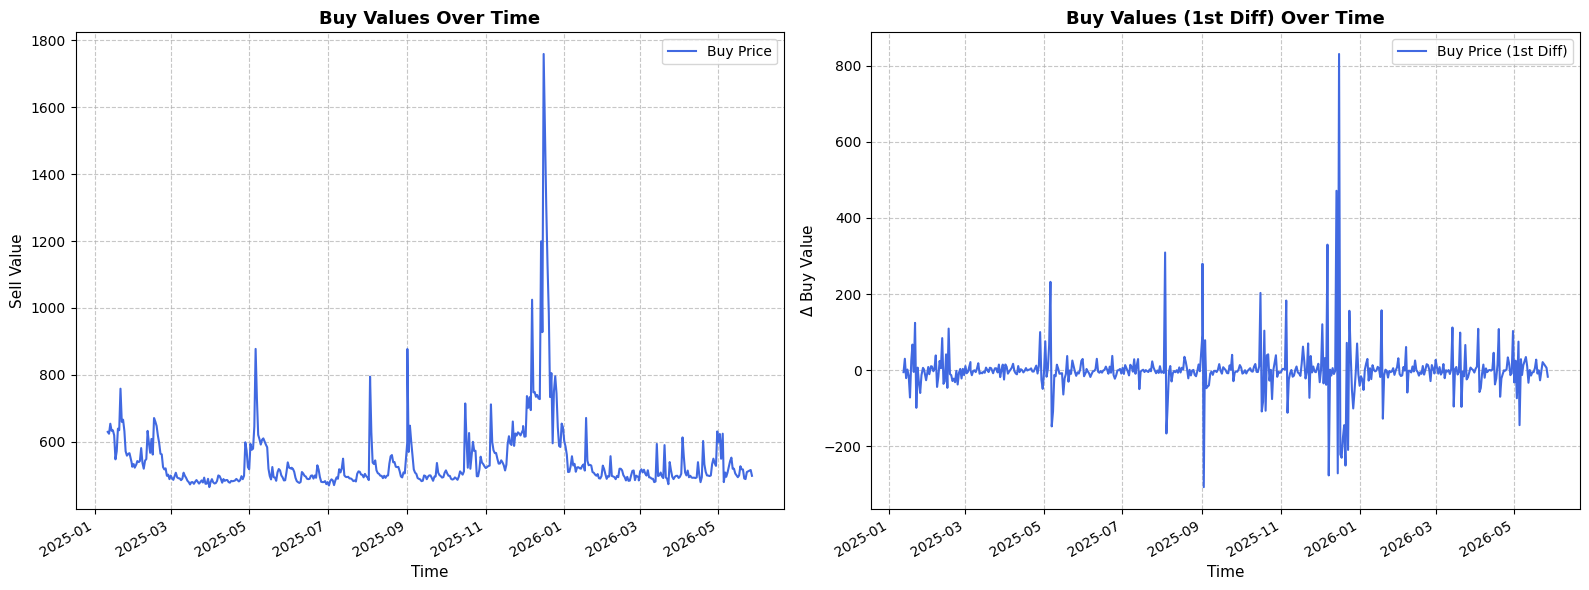

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PLOT: Raw Buy Price
ax1.plot(cleaned_data['timestamp'], cleaned_data['buy'], 
         label='Buy Price', color='royalblue', linewidth=1.5)

ax1.set_title('Buy Values Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time', fontsize=11)
ax1.set_ylabel('Sell Value', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# RIGHT PLOT: 1st Differenced
ax2.plot(differenced_data['timestamp'], differenced_data['diff_buy'], 
         label='Buy Price (1st Diff)', color='royalblue', linewidth=1.5)

ax2.set_title('Buy Values (1st Diff) Over Time', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('$\Delta$ Buy Value', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

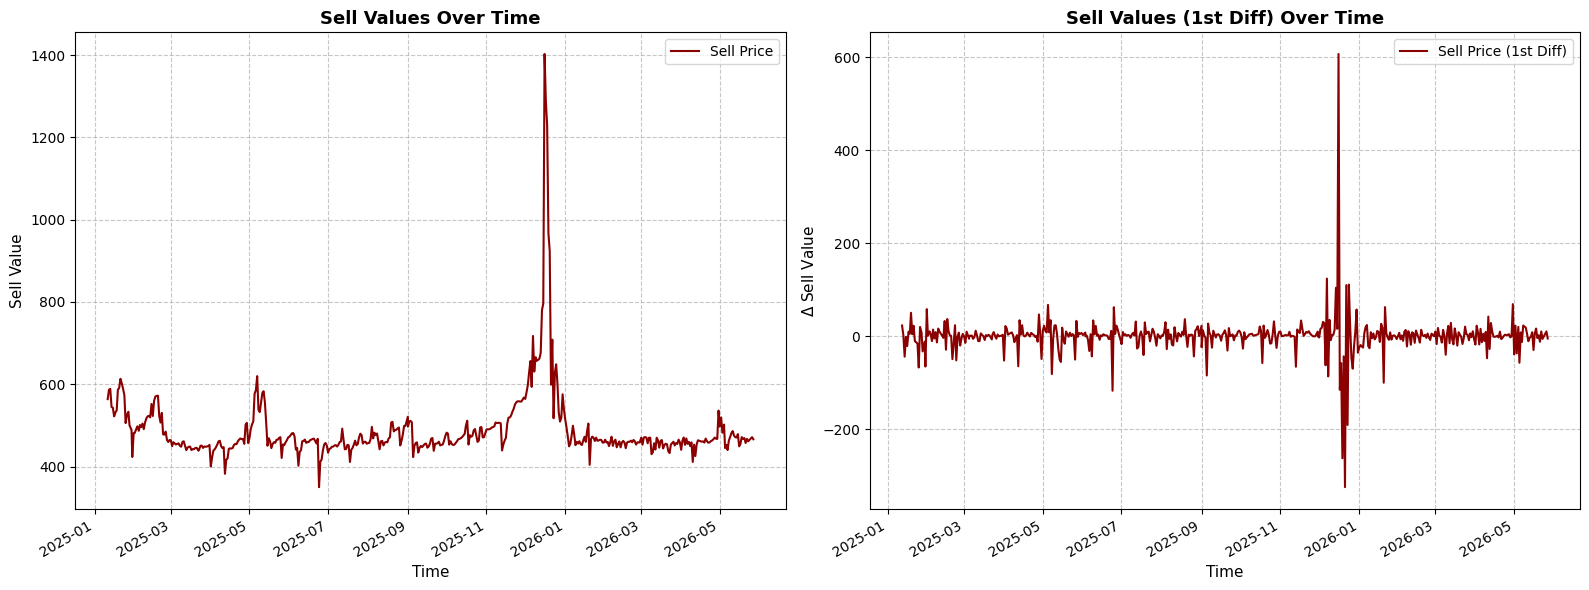

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PLOT: Raw Sell Price
ax1.plot(cleaned_data['timestamp'], cleaned_data['sell'], 
         label='Sell Price', color='darkred', linewidth=1.5)

ax1.set_title('Sell Values Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time', fontsize=11)
ax1.set_ylabel('Sell Value', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# RIGHT PLOT: 1st Differenced
ax2.plot(differenced_data['timestamp'], differenced_data['diff_sell'], 
         label='Sell Price (1st Diff)', color='darkred', linewidth=1.5)

ax2.set_title('Sell Values (1st Diff) Over Time', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('$\Delta$ Sell Value', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()